In [1]:
from metasyn import demo_data, MetaFrame
from metasyn.builder import MetaFrameBuilder
from metasyn.privacy import BasicPrivacy
import numpy as np
import polars as pl
from matplotlib import pyplot as plt
from metasyn.distribution import ContinuousNormalDistribution, ContinuousUniformDistribution, ContinuousConstantDistribution
from metasyn.distribution.base import ColumnReference

/home/matty/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def plot_dataframe(df):
    plt.scatter(df["base"], df["correlated"], label="correlated")
    plt.scatter(df["base"], df["larger"], label="larger")
    plt.plot(df["base"], df["base"], label="base")
    plt.scatter(df["base"], df["linear"], label="linear")
    plt.legend()
    plt.show()

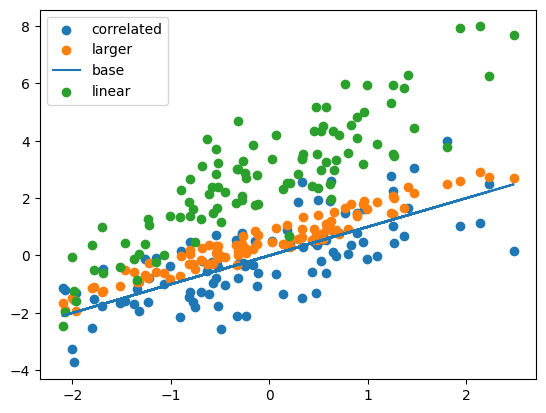

In [3]:
base = np.random.randn(100)
corr = np.random.randn(100) + base
constrained = np.random.rand(100) + base
linear = 3+2*base + np.random.randn(100)
df = pl.DataFrame({"base": base, "correlated": corr, "larger": constrained, "linear": linear})
plot_dataframe(df)


In [5]:
df

base,correlated,larger,linear
f64,f64,f64,f64
0.456225,0.481757,0.916215,4.325825
-0.910623,-2.139025,-0.71324,1.356136
2.233878,2.480291,2.727328,6.273255
0.48508,0.35555,0.539418,3.535816
-0.544476,0.729091,0.101651,3.700085
…,…,…,…
-0.162508,-0.324971,0.23846,3.838963
-1.695253,-1.762402,-1.26089,0.993231
1.804671,3.997561,2.486424,3.768224


In [9]:
builder = MetaFrameBuilder()
builder.privacy = BasicPrivacy()
builder.n_rows = 100
builder.add_column("base", var_type="continuous")
builder["base"].distribution = ContinuousNormalDistribution(0, 1)
builder.add_column("correlated", var_type="continuous")
builder["correlated"].distribution = ColumnReference("base") + ContinuousNormalDistribution(0, 1)
builder.add_column("larger", var_type="continuous")
builder["larger"].distribution = ColumnReference("base") + ContinuousUniformDistribution(0, 1)
builder.add_column("linear", var_type="continuous")
builder["linear"].distribution = ContinuousConstantDistribution(3.0) + ContinuousConstantDistribution(2)*ColumnReference("base") + ContinuousNormalDistribution(0, 1)
mf = builder.fit()
# builder.add_column("C", hidden=True)
# builder["C"].distribution = ColumnReference("A") - ColumnReference("B")
# builder["C"].ge_zero = True
# builder["B"].distribution = ColumnReference("A") + ColumnReference("C")
# builder["B"].distribution = ColumnReference("A") + ColumnReference("B.fitter")

100%|██████████| 4/4 [00:00<00:00, 15321.66it/s]


  correlated: 100%|██████████| 4/4 [00:00<00:00, 265.50variables/s]


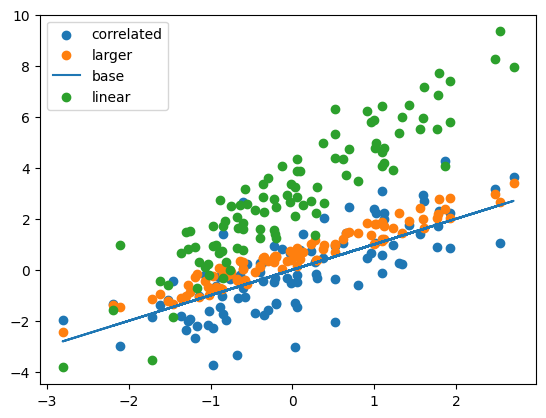

In [10]:
df_syn = mf.synthesize(100)
plot_dataframe(df_syn)